<a href="https://colab.research.google.com/github/Yennhinn/github-portfolio/blob/main/Dating_App_Lovoo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction
---
The goal of this notebook is to analyze the factors that make people more attractive on the Lovoo dating app, thereby helping users build a more prominent online dating profile so they can more easily find a match (based on profile views, number of received kisses, and number of received gifts).

Members:
*   Do Phuong Mai
*   Nguyen Ngoc Yen Nhi
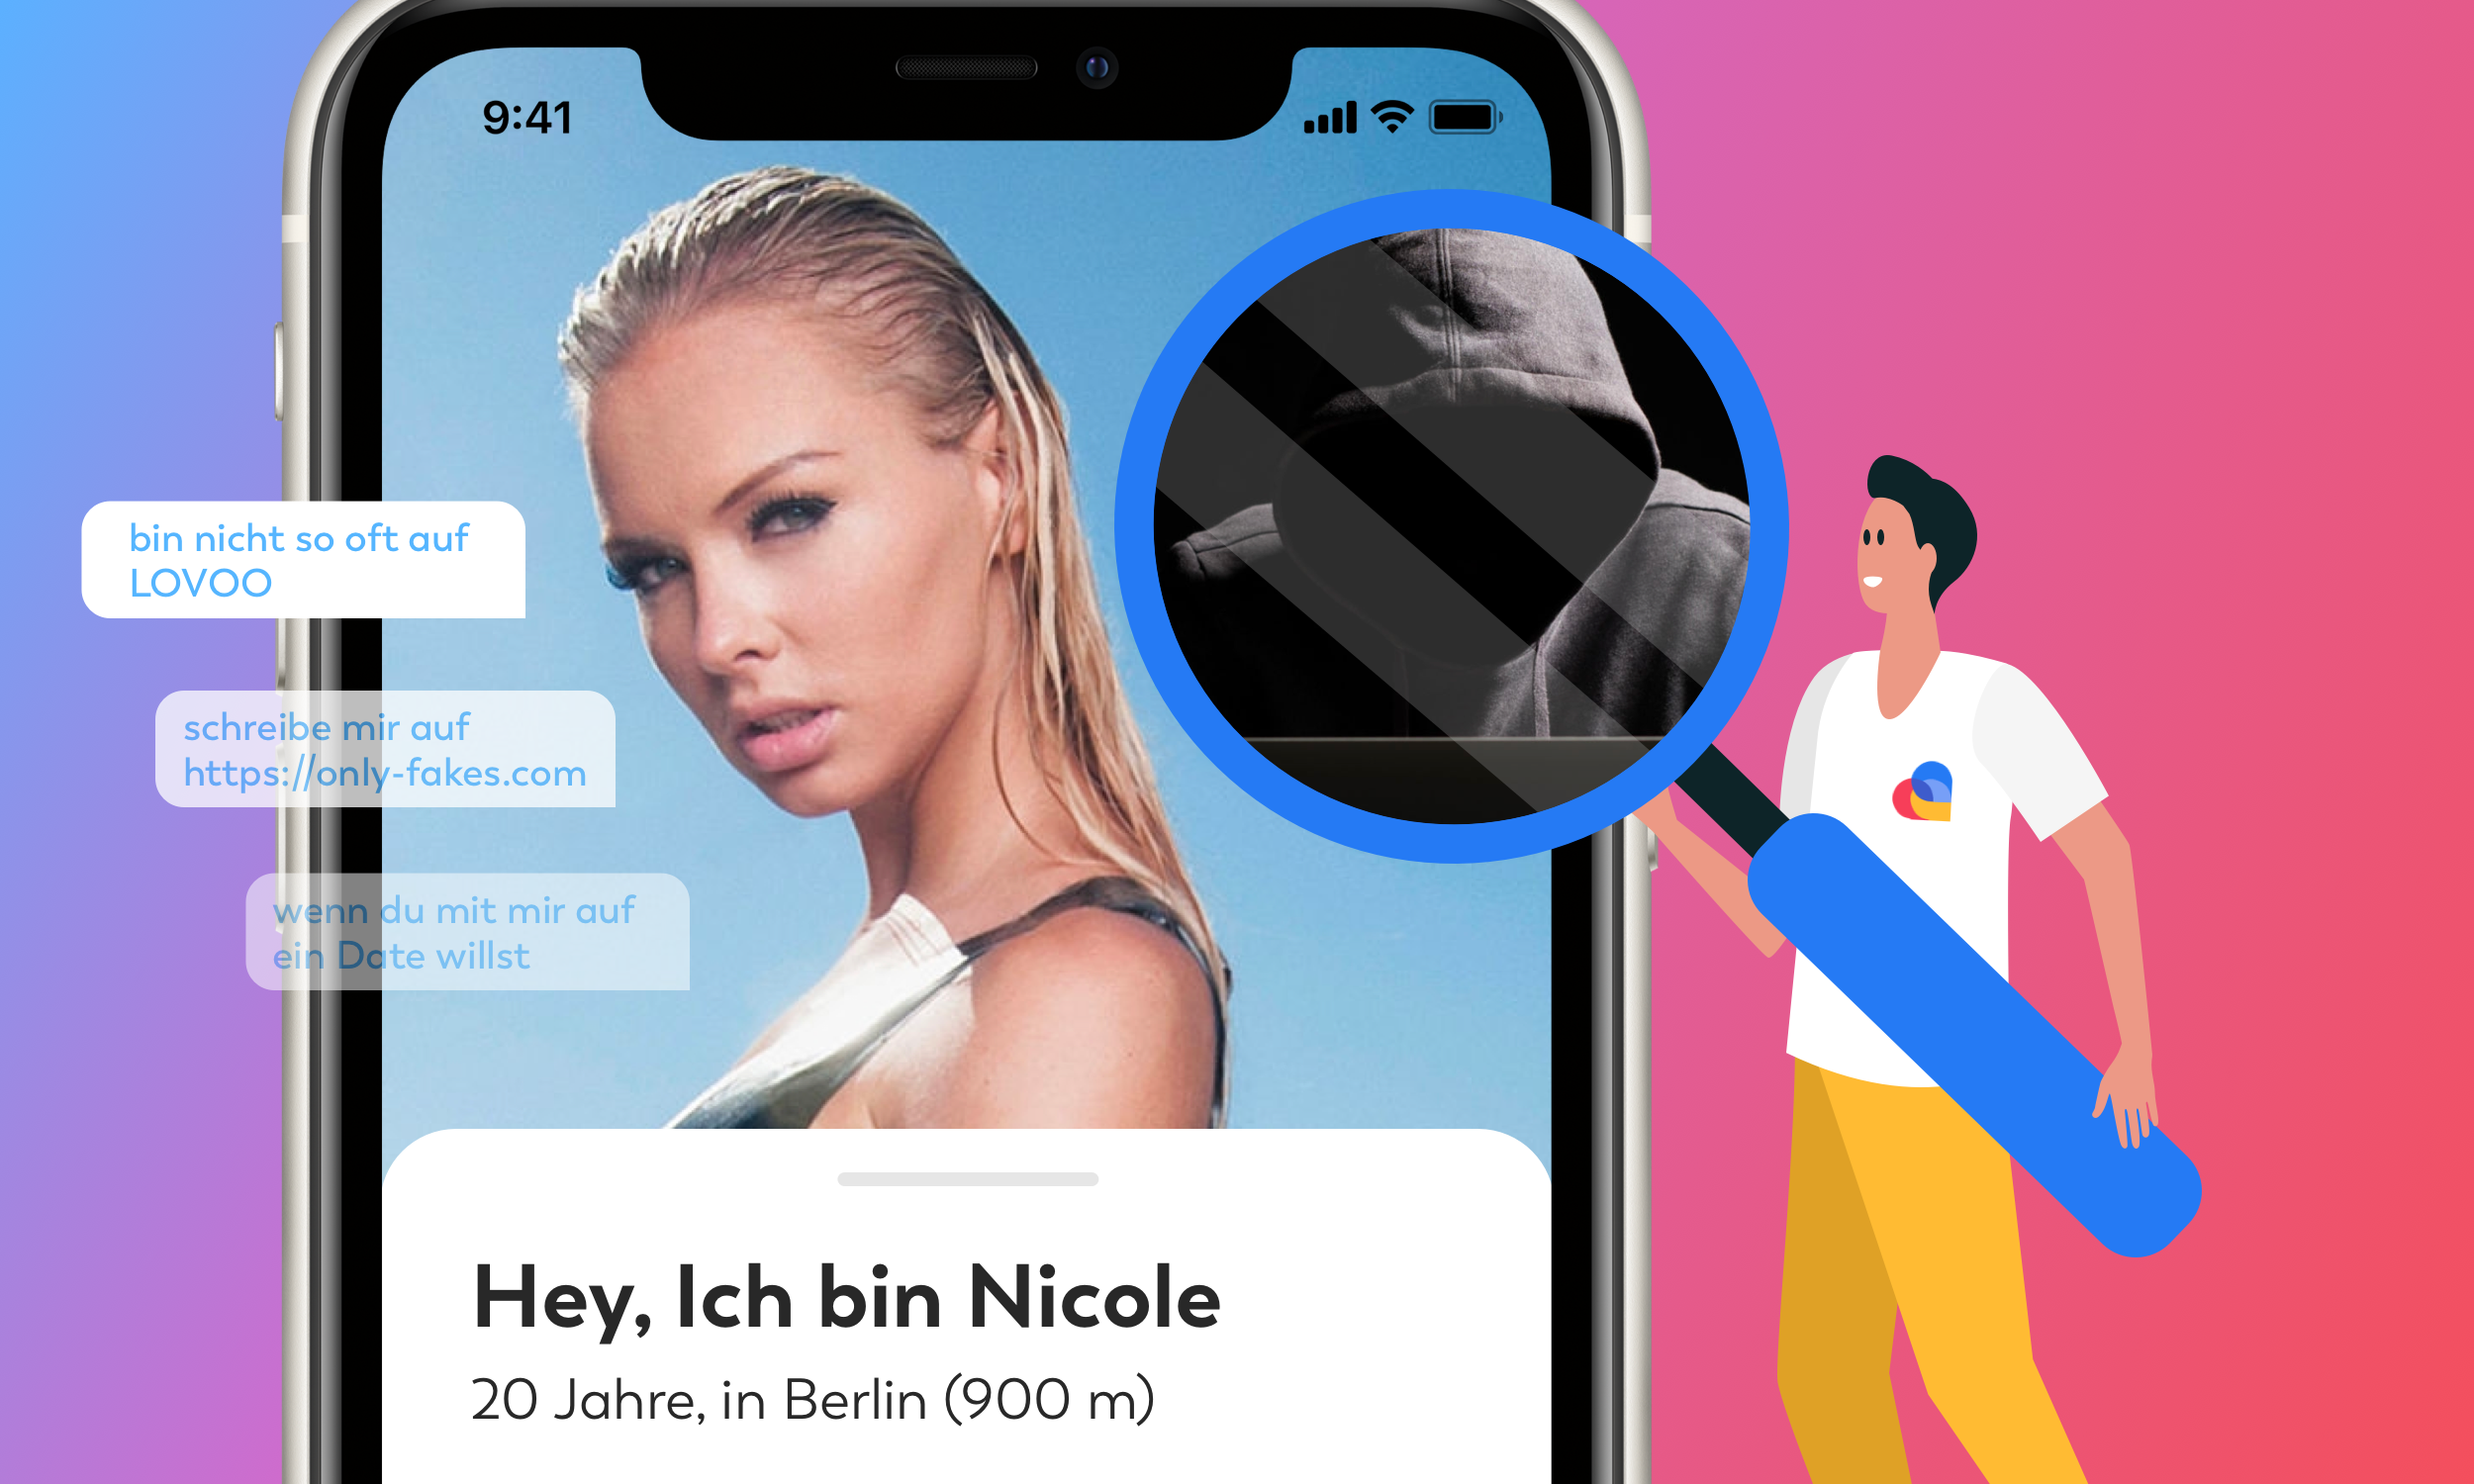

Methods: Correlation Matrix, Scatter Plot - Linear Regression

The content of the Notebook includes:
1. Overview of the dataset
2. EDA
3. Analysis
4. Conclusion

# 1. Overview of the Dataset
The dataset contains user profile information from Lovoo dating app.
The data was collected in the spring of 2015 (April and May). At that time, Lovoo was expanding in European countries, while Tinder was popular in both the US and Europe.

The dataset includes 3,973 samples, corresponding to 3,973 users (female, aged between 18 and 28, from several European countries).

The dataset includes 16 columns, corresponding to the following 16 attributes:
- gender: The user's gender
- gender_looking: The gender the user is looking for
- age: The user's age
- name: The user's name
- counts_profileVisits: Number of times the user's profile has been viewed
- counts_kisses: Number of kisses (likes) the user has received
- counts_g: Number of gifts the user has received
- counts_details: Level of detail in the information the user has provided
- counts_pictures: Number of pictures the user has uploaded
- country: Country of residence
- distance: Desired distance
- isFlirtstar: Whether the user is a "flirtstar"
- isVip: Whether the user is a VIP
- lang_count: Number of languages the user knows
- verified: Whether the user's account is verified
- isNew: Whether the user is new to the app

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objs as go
import plotly.express as px
import seaborn as sns

In [ ]:
df = pd.read_csv('lovoo_v3_users_dataset.csv')
df

,gender,genderLooking,age,name,counts_profileVisits,counts_kisses,counts_g,counts_details,counts_pictures,country,distance,isFlirtstar,isVip,lang_count,verified,isNew
0,F,M,25,daeni,8279,239,3,1.00,4,CH,175.0,0,0,1,0,0
1,F,M,22,italiana 92,663,13,0,0.85,5,CH,138.0,0,0,3,0,0
2,F,M,21,Lauraaa,1369,88,2,0.00,4,CH,137.0,0,0,0,0,0
3,F,none,20,Qqkwmdowlo,22187,1015,3,0.12,3,CA,77.3,0,0,2,0,0
4,F,M,21,schaessie {3,35262,1413,12,0.15,12,DE,286.0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3968,F,M,21,B**f,280,15,0,0.85,1,TR,NaN,0,0,1,0,0
3969,F,M,20,Ma**e,1014,43,0,1.00,8,CH,NaN,0,0,1,0,0
3970,F,M,20,Ma**e,1101,46,0,1.00,8,CH,NaN,0,0,1,0,0
3971,F,M,23,Eni**n,8702,142,0,0.96,8,CH,NaN,0,0,2,0,0


In [ ]:
df.describe()

,age,counts_profileVisits,counts_kisses,counts_g,counts_details,counts_pictures,distance,isFlirtstar,isVip,lang_count,verified,isNew
count,3973.000000,3973.000000,3973.000000,3973.000000,3973.000000,3973.000000,3946.000000,3973.000000,3973.000000,3973.000000,3973.000000,3973.000000
mean,21.995973,3710.107727,157.022653,0.126101,0.568369,4.789831,207.230005,0.011830,0.022905,1.109237,0.220992,0.239869
std,1.961868,6857.418509,378.487718,1.241874,0.325983,4.425150,196.594017,0.108133,0.149618,0.583119,0.414967,0.427057
min,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,20.000000,384.000000,11.000000,0.000000,0.310000,2.000000,83.875000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,22.000000,1237.000000,44.000000,0.000000,0.620000,4.000000,172.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,24.000000,4061.000000,141.000000,0.000000,0.850000,6.000000,317.000000,0.000000,0.000000,1.000000,0.000000,0.000000
max,28.000000,164425.000000,9288.000000,43.000000,1.000000,30.000000,6918.000000,1.000000,1.000000,9.000000,1.000000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3973 entries, 0 to 3972
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   gender                3973 non-null   object 
 1   genderLooking         3973 non-null   object 
 2   age                   3973 non-null   int64  
 3   name                  3973 non-null   object 
 4   counts_profileVisits  3973 non-null   int64  
 5   counts_kisses         3973 non-null   int64  
 6   counts_g              3973 non-null   int64  
 7   counts_details        3973 non-null   float64
 8   counts_pictures       3973 non-null   int64  
 9   country               3973 non-null   object 
 10  distance              3946 non-null   float64
 11  isFlirtstar           3973 non-null   int64  
 12  isVip                 3973 non-null   int64  
 13  lang_count            3973 non-null   int64  
 14  verified              3973 non-null   int64  
 15  isNew                

# 2. EDA
Describe some characteristics of user accounts on the Lovoo dating app, such as the gender they are looking for, age, profile detail level, and the number of photos they have uploaded.



## 2.1. Gender Looking

In [ ]:
gender_counts = df['genderLooking'].value_counts()

fig = go.Figure(data=[go.Pie(labels=gender_counts.index,
                             values=gender_counts.values,
                             pull=[0.1, 0, 0, 0],
                             textinfo='label+percent')])

fig.update_layout(title_text='Distribution of Preferred Gender')
fig.show()

- 89.6% of users are females looking for males
- 9.21% are not searching for anyone
- 0.629% are females looking for females
- The remaining 0.561% are females looking for both (males and females)

## 2.2. Age

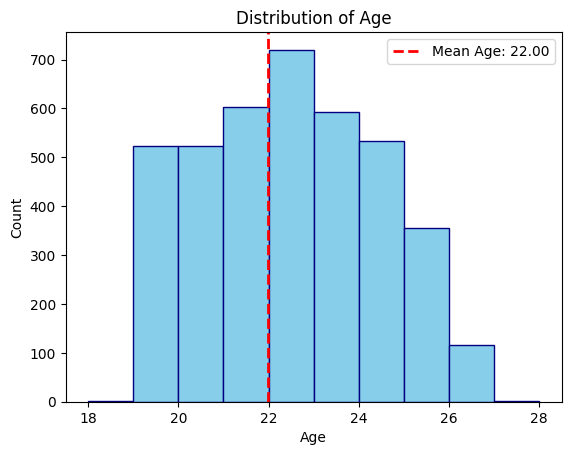

In [ ]:
mean_age = df['age'].mean()

plt.hist(df['age'], bins=10, color='skyblue', edgecolor='navy')
plt.axvline(mean_age, color='red', linestyle='dashed', linewidth=2, label=f'Mean Age: {mean_age:.2f}')
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Distribution of Age')
plt.legend()
plt.show()

The average age is 22 years old.

## 2.3. Account details

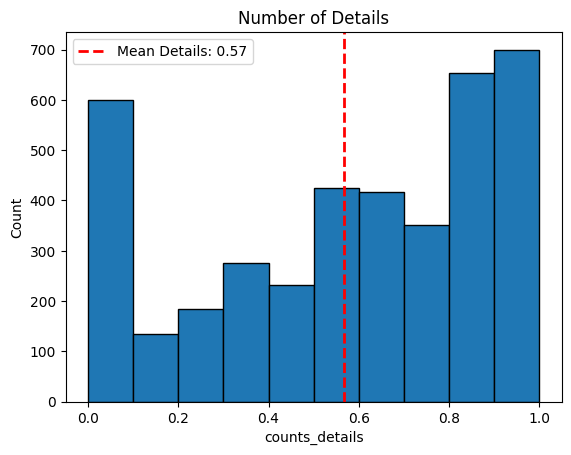

In [ ]:
mean_details = df['counts_details'].mean()

plt.hist(df['counts_details'], bins=10, edgecolor='black')
plt.axvline(mean_details, color='red', linestyle='dashed', linewidth=2, label=f'Mean Details: {mean_details:.2f}')
plt.xlabel('counts_details')
plt.ylabel('Count')
plt.title('Number of Details')
plt.legend()
plt.show()

The average level of detail in the information provided by users is approximately 0.6 (evaluated based on Lovoo's profile completeness scale from 0 to 1).

## 2.4. Number of Pictures Uploaded

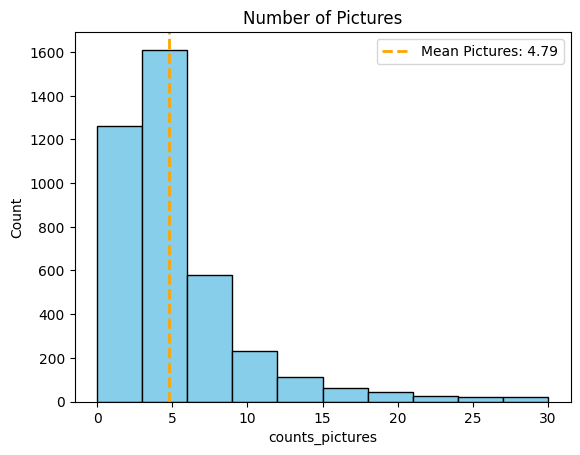

In [ ]:
mean_pictures = df['counts_pictures'].mean()

plt.hist(df['counts_pictures'], bins=10, edgecolor='black', color='skyblue')

plt.axvline(mean_pictures, color='orange', linestyle='dashed', linewidth=2, label=f'Mean Pictures: {mean_pictures:.2f}')  # Changed color to orange
plt.xlabel('counts_pictures')
plt.ylabel('Count')
plt.title('Number of Pictures')
plt.legend()
plt.show()

The average number of pictures uploaded by users is 5.

# 3. Analysis
---
This part analyzes the factors that affect counts_profileVisits, counts_kisses and counts_g. The relationship between the above variables is shown as follows:


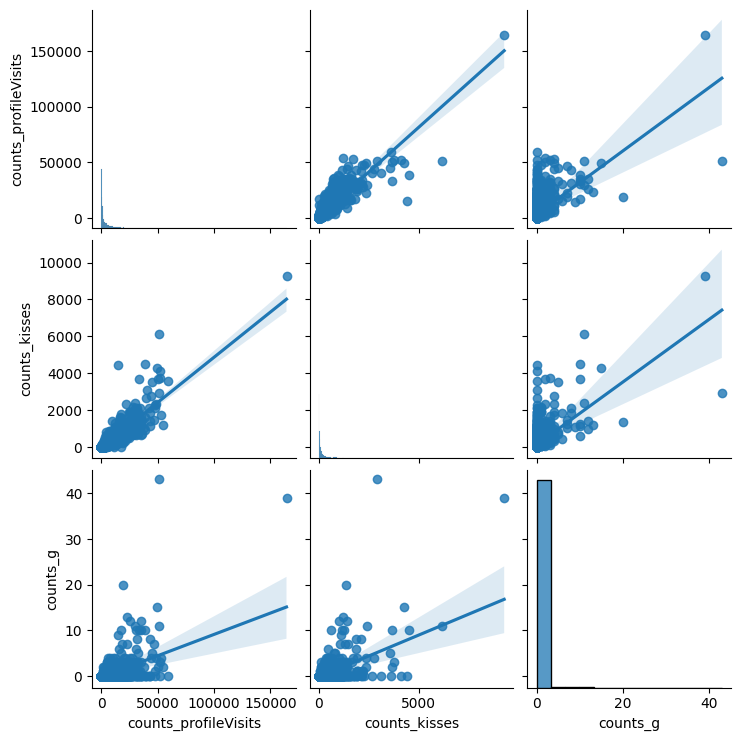

In [ ]:
sns.pairplot(df, vars=["counts_profileVisits", "counts_kisses", "counts_g"], kind="reg")

*   The strongest correlation is between counts_kisses and counts_profileVisits.

=> accounts with more profile visits tend to receive more kisses.

*   The variable counts_g also shows a relatively strong positive correlation with both counts_kisses and counts_profileVisits.

=> the number of gifts received is also closely related to the number of kisses and profile visits.

*  There are some data points that deviate from the general trend line. This could be due to the influence of other factors, such as the level of profile detail, number of photos, etc.

**All three variables — counts_profileVisits, counts_kisses, and counts_g — exhibit positive correlations with one another. This means that when one variable increases, the others also tend to increase. However, the correlation is not perfectly linear and may be influenced by other factors.**

## 3.1. Correlation Matrix

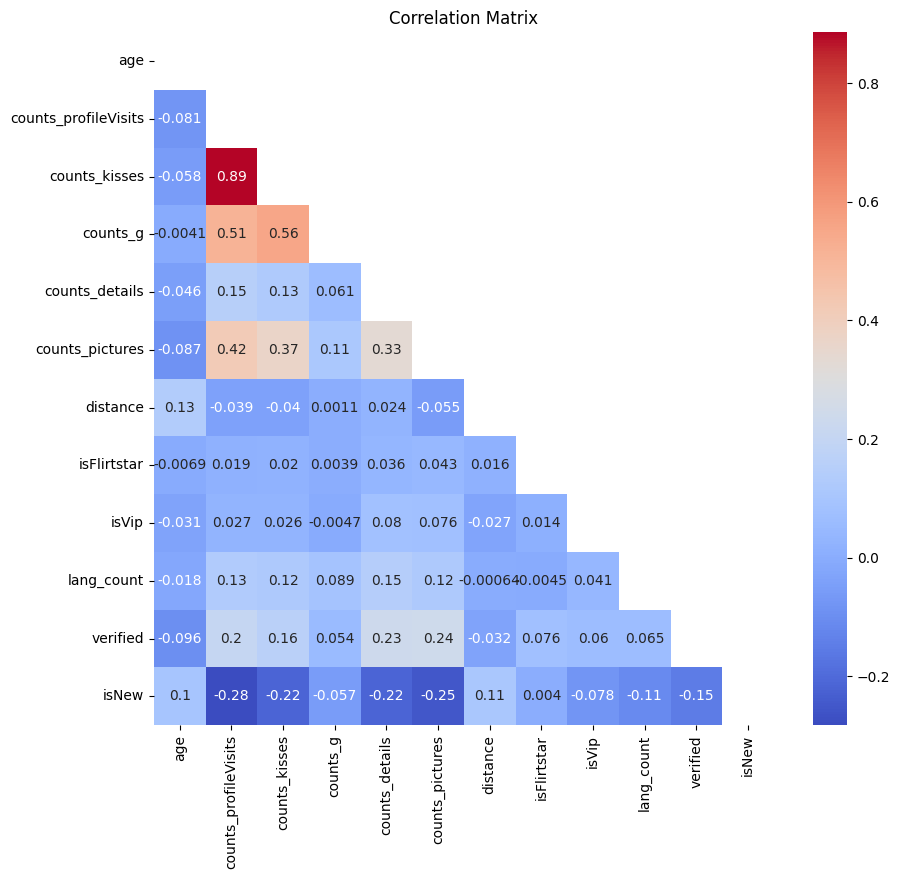

In [ ]:
numeric_features = df.select_dtypes(include=['float', 'int',]).columns

correlation_matrix = df[numeric_features].corr()

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

plt.figure(figsize=(10, 9))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

**Besides the relationships between labels (counts_profileVisits, counts_kisses, and counts_g) mentioned above, the correlation matrix also reveals the following insights:**

*   **counts_pictures** has a moderate correlation with **counts_profileVisits (0.42)** and **counts_kisses (0.37)**  
=> Users with more profile pictures also tend to receive more profile visits and kisses.

*   **verified** has a correlation with **counts_pictures (0.23)**, **counts_profileVisits (0.20)**, and **counts_kisses (0.16)**  
=> Verified accounts tend to have more pictures, more profile visits, and more kisses.

*   **isFlirtstar** and **isVip** do not show strong correlations with any other variables  
=> Being a Flirtstar or VIP is not necessarily related to other behaviors or characteristics.

*   **isNew** shows the strongest negative correlation with other variables  
=> New users tend to have lower values across other engagement metrics.









## 3.2. Scatter Plots and Linear Regression
---
Analyze each factor that affects the variables: Profile Visits, Number of Kisses, and Number of Gifts received

Scatter plot and linear regression
---
**Scatter plots** are a type of chart that uses data points to represent the relationship between two variables. The position of each data point on the chart indicates the values of both variables for that observation.

**Linear regression** is a straight line that represents the average relationship between two numerical variables.

**Confidence intervals** provide an estimate of the uncertainty around the regression line. They show a range within which we can be confident the true relationship lies. Typically, a 95% confidence interval is used, meaning we are 95% confident that the true regression line falls within this range.


In [ ]:
plot_settings = [
    ('counts_profileVisits', 'Number of Profile Visits'),
    ('counts_kisses', 'Number of Kisses Received'),
    ('counts_g', 'Number of Gifts Received')
]

### counts_details

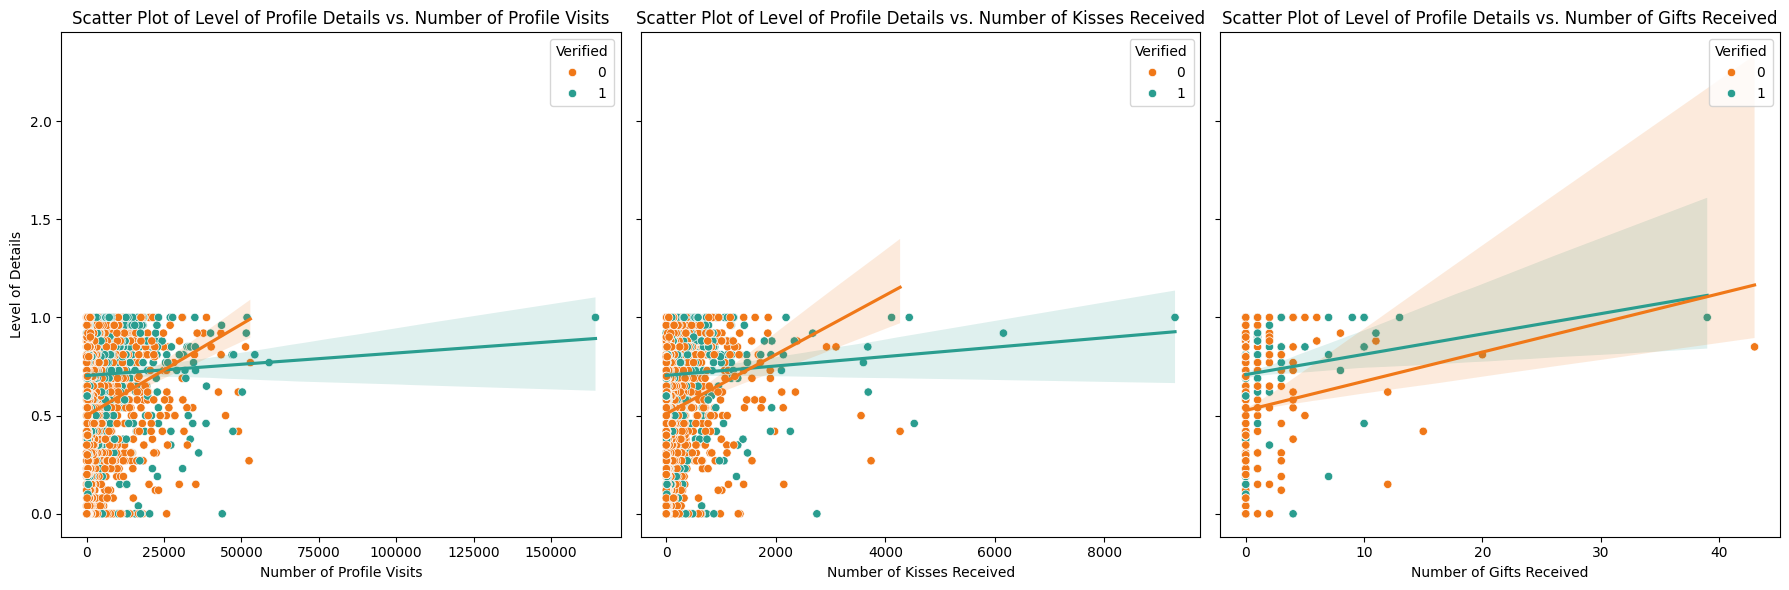

In [ ]:
# Subplot
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, (x_col, x_label) in enumerate(plot_settings):
    ax = axes[i]
    sns.scatterplot(
        data=df, x=x_col, y='counts_details', hue='verified',
        palette={True: '#2A9D8F', False: '#F07818'}, ax=ax
    )
    sns.regplot(
        data=df[df['verified'] == True], x=x_col, y='counts_details',
        scatter=False, color='#2A9D8F', ax=ax
    )
    sns.regplot(
        data=df[df['verified'] == False], x=x_col, y='counts_details',
        scatter=False, color='#F07818', ax=ax
    )
    ax.set_xlabel(x_label)
    ax.set_ylabel('Level of Details' if i == 0 else '')
    ax.legend(title='Verified')
    ax.set_title(f'Scatter Plot of Level of Profile Details vs. {x_label}')

plt.tight_layout()
plt.show()

*   The regression line shows a slight upward trend => more detailed profiles tend to receive more interactions.
*   Users without verification but with detailed descriptions tend to receive more kisses on average.
*   Verified accounts with low profile detail show less variance.

=> More detailed profiles may attract more interactions, especially when verified, though the impact is not very significant.

### counts_pictures


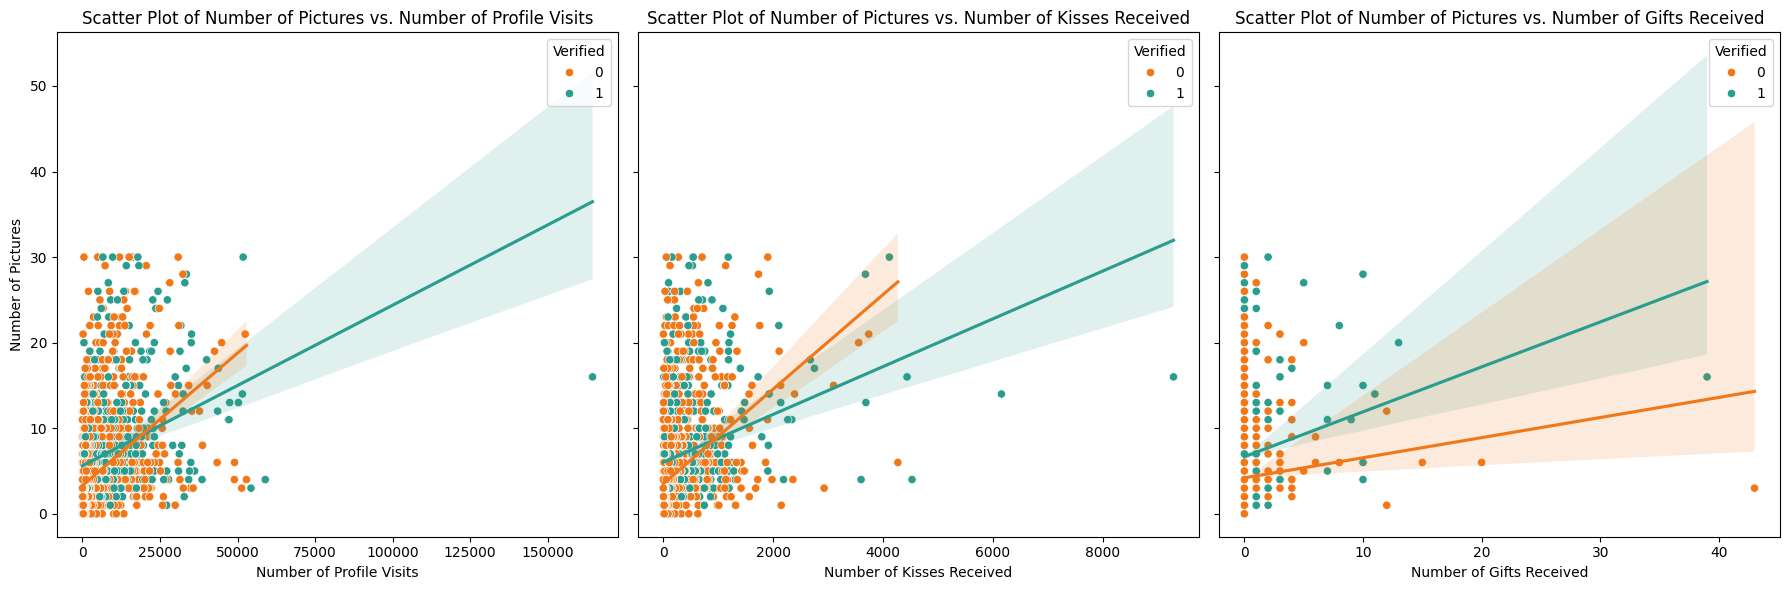

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, (x_col, x_label) in enumerate(plot_settings):
    ax = axes[i]
    sns.scatterplot(
        data=df, x=x_col, y='counts_pictures', hue='verified',
        palette={True: '#2A9D8F', False: '#F07818'}, ax=ax
    )
    sns.regplot(
        data=df[df['verified'] == True], x=x_col, y='counts_pictures',
        scatter=False, color='#2A9D8F', ax=ax
    )
    sns.regplot(
        data=df[df['verified'] == False], x=x_col, y='counts_pictures',
        scatter=False, color='#F07818', ax=ax
    )
    ax.set_xlabel(x_label)
    ax.set_ylabel('Number of Pictures' if i == 0 else '')
    ax.legend(title='Verified')
    ax.set_title(f'Scatter Plot of Number of Pictures vs. {x_label}')

plt.tight_layout()
plt.show()

*   There is a positive relationship between the number of uploaded pictures and the variables: profile visits, number of kisses received, and number of gifts received.
*   Verified users tend to show less variance and a clearer positive correlation compared to non-verified users.

=> This suggests that adding more pictures—especially in verified accounts—may enhance user engagement.

### distance

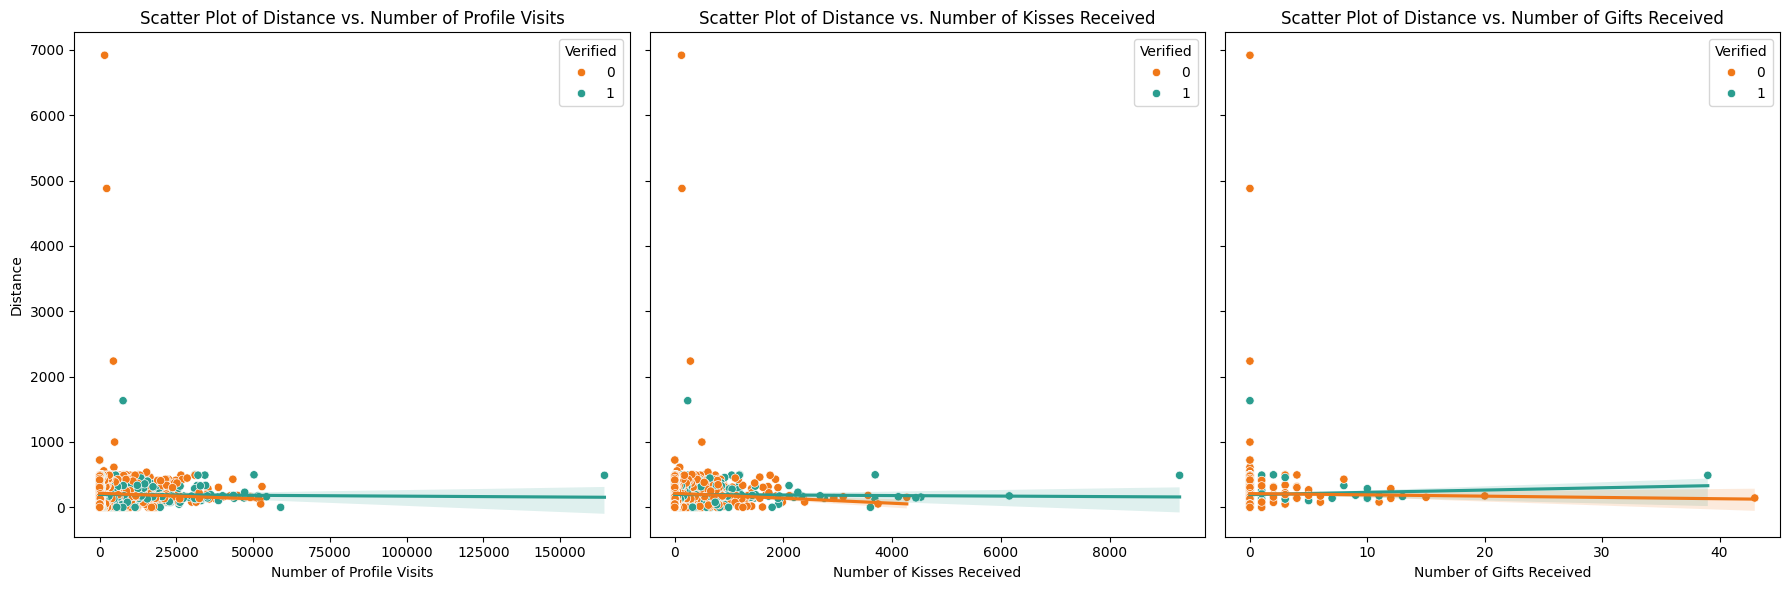

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, (x_col, x_label) in enumerate(plot_settings):
    ax = axes[i]
    sns.scatterplot(
        data=df, x=x_col, y='distance', hue='verified',
        palette={True: '#2A9D8F', False: '#F07818'}, ax=ax
    )
    sns.regplot(
        data=df[df['verified'] == True], x=x_col, y='distance',
        scatter=False, color='#2A9D8F', ax=ax
    )
    sns.regplot(
        data=df[df['verified'] == False], x=x_col, y='distance',
        scatter=False, color='#F07818', ax=ax
    )
    ax.set_xlabel(x_label)
    ax.set_ylabel('Distance' if i == 0 else '')
    ax.legend(title='Verified')
    ax.set_title(f'Scatter Plot of Distance vs. {x_label}')

plt.tight_layout()
plt.show()

*   Across all three plots, data points are densely clustered at lower distance values, with some outliers at higher distances. However, these outliers are mostly unverified accounts with low interaction levels.

*   The regression lines show only slight trends, but overall there does not appear to be a significant correlation between distance and the labels.

*   Account verification status also does not seem to have a notable impact.

### lang_count

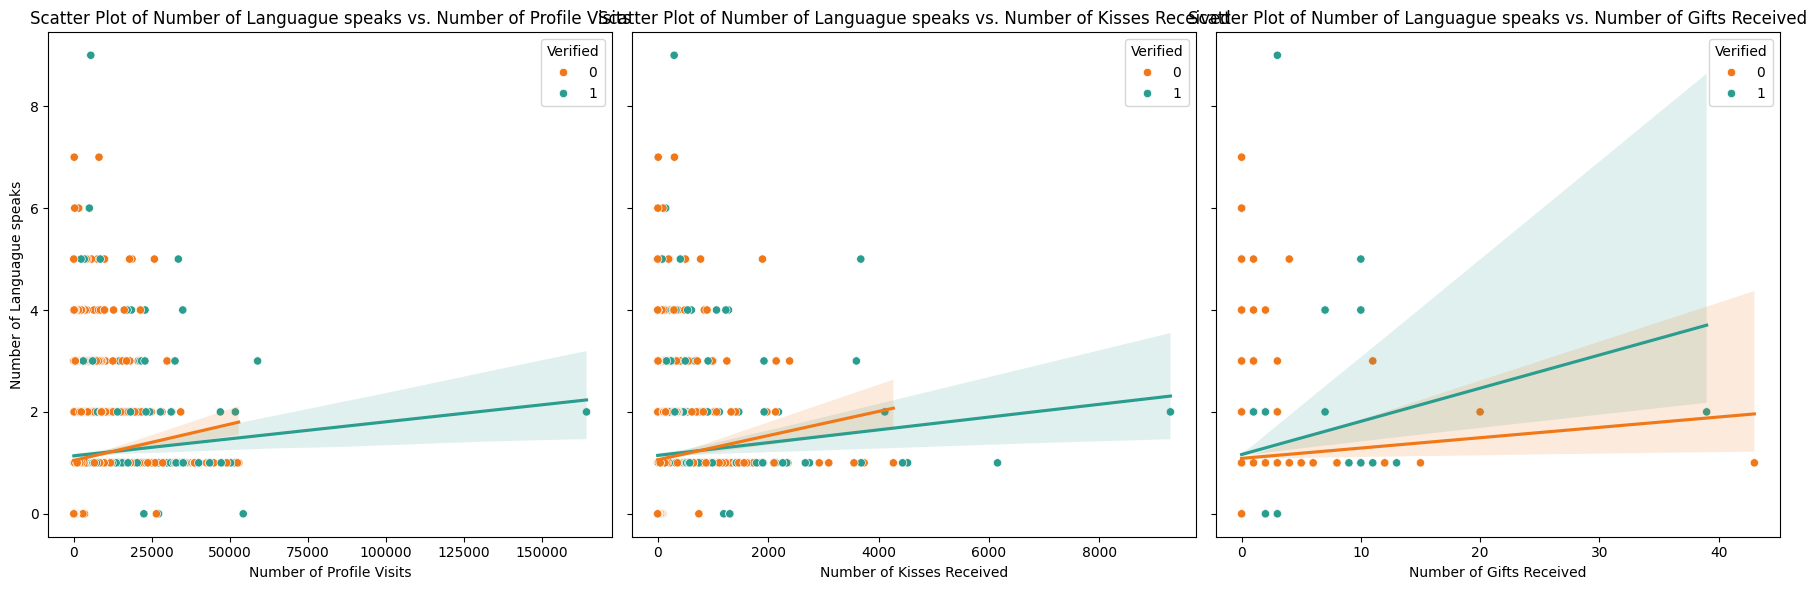

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, (x_col, x_label) in enumerate(plot_settings):
    ax = axes[i]
    sns.scatterplot(
        data=df, x=x_col, y='lang_count', hue='verified',
        palette={True: '#2A9D8F', False: '#F07818'}, ax=ax
    )
    sns.regplot(
        data=df[df['verified'] == True], x=x_col, y='lang_count',
        scatter=False, color='#2A9D8F', ax=ax
    )
    sns.regplot(
        data=df[df['verified'] == False], x=x_col, y='lang_count',
        scatter=False, color='#F07818', ax=ax
    )
    ax.set_xlabel(x_label)
    ax.set_ylabel('Number of Languague speaks' if i == 0 else '')
    ax.legend(title='Verified')
    ax.set_title(f'Scatter Plot of Number of Languague speaks vs. {x_label}')

plt.tight_layout()
plt.show()

*   The regression lines show a slight upward trend, indicating a mild positive correlation between the number of spoken languages and profile visits, kisses received, or gifts received.
*   Verification status does not appear to significantly affect this relationship.

### isNew

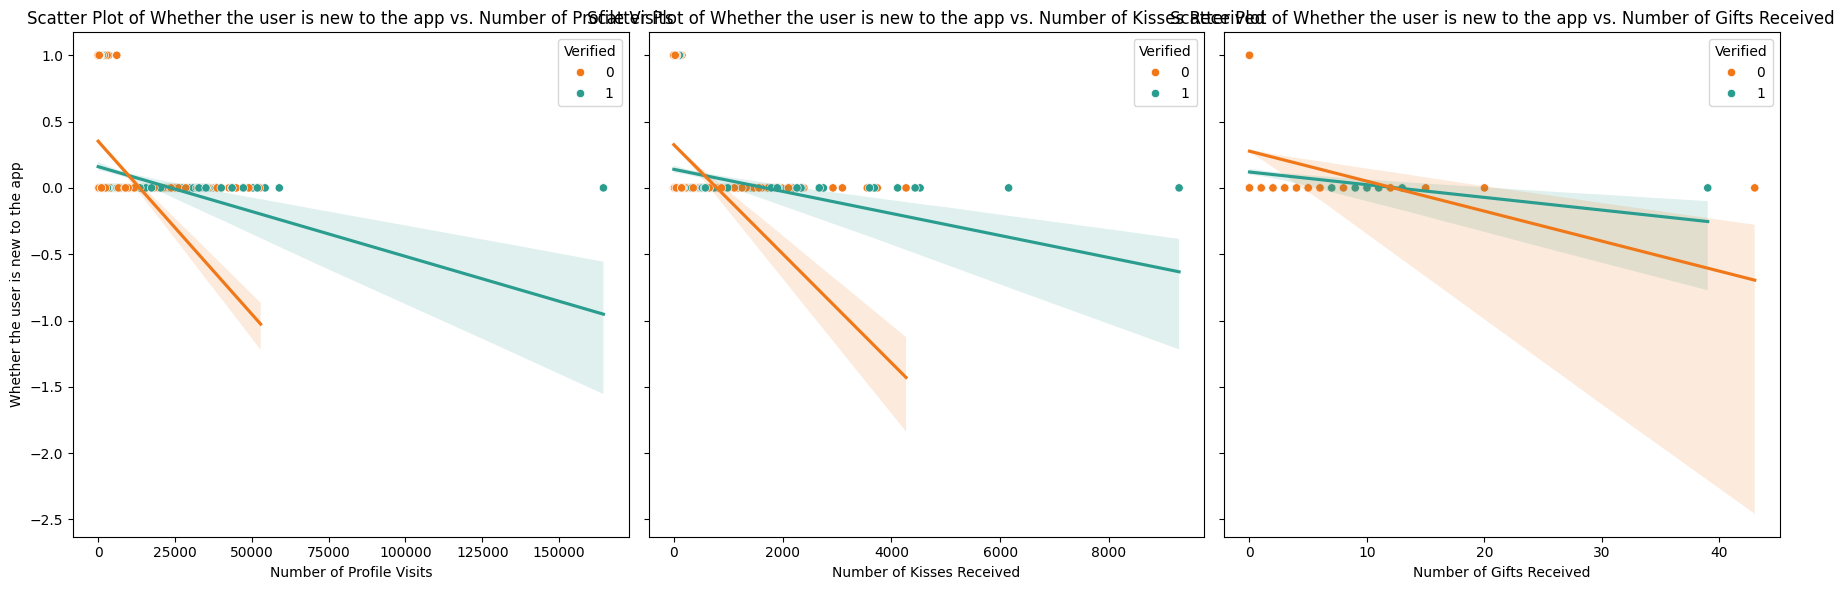

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, (x_col, x_label) in enumerate(plot_settings):
    ax = axes[i]
    sns.scatterplot(
        data=df, x=x_col, y='isNew', hue='verified',
        palette={True: '#2A9D8F', False: '#F07818'}, ax=ax
    )
    sns.regplot(
        data=df[df['verified'] == True], x=x_col, y='isNew',
        scatter=False, color='#2A9D8F', ax=ax
    )
    sns.regplot(
        data=df[df['verified'] == False], x=x_col, y='isNew',
        scatter=False, color='#F07818', ax=ax
    )
    ax.set_xlabel(x_label)
    ax.set_ylabel('Whether the user is new to the app' if i == 0 else '')
    ax.legend(title='Verified')
    ax.set_title(f'Scatter Plot of Whether the user is new to the app vs. {x_label}')

plt.tight_layout()
plt.show()

*   The regression lines show a downward trend, which is especially pronounced among unverified users.

=> New users on this app tend to receive fewer interactions, particularly those with unverified accounts.

# 4. Conclusion
---
Based on the above analyses, we offer some recommendations for those who want to succeed on dating apps:

*   Upload many pictures
*   Provide a more detailed self-description
*   Verify your account
*   Be patient, as new user accounts tend to have less interaction, especially if they are unverified. People may perceive such accounts as unreliable or fake.

Additionally, note that achieving titles like Flirtstar or similar on other dating apps and spending money on the app have little impact on your popularity within the app. Therefore, it is not worth wasting effort or money on these.

After others visit your profile, the probability of receiving a kiss (like) is 89% (which also means your chances of matching with them increase). Following that, you have over a 50% chance of receiving a gift from a matched user.
